## Imports

In [ ]:
import os
import sys
import json
from datetime import datetime
from pathlib import Path

import random
import numpy as np
import wandb
import torch
from torch_geometric.loader import DataLoader

base_dir = Path('/mnt/e/fyassine/+ad-early-detection')
sys.path.insert(0, str(base_dir))

import config

from model.GAAE.models import GraphAttentionAutoencoderConditioned
from model.GAAE.dataset import GraphDatasetInMemoryFiltered
from model.GAAE.utils import knn_binary_adjacency_matrix_no_diag
from model.GAAE.train import train_model_with_val_notebook_train_loss


## Configuration

In [ ]:
os.environ['WANDB_API_KEY'] = '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'
try:
    wandb.login()
except Exception:
    pass

WANDB_PROJECT = "converters-vs-nonconverters"

wandb: Currently logged in as: lakhalfrajyassine (lakhalfrajyassine-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
hyperparams_path = base_dir / "configs" / "gaae_dancer.json"
with open(hyperparams_path, "r") as handle:
    hyperparams = json.load(handle)

seed = hyperparams["seed"]
batch_size = hyperparams["batch_size"]
learning_rate = hyperparams["learning_rate"]
adj_loss_weight = hyperparams["adj_loss_weight"]
n_epochs = hyperparams["epochs"]
early_stopping_patience = hyperparams["early_stopping_patience"]

out_features = hyperparams["latent_dim"]
num_heads = hyperparams["num_heads"]
cond_dim = hyperparams["cond_dim"]
dropout = hyperparams["dropout"]
model_save_path = hyperparams.get("model_save_path")

adjacency_args = {"k": hyperparams["adjacency_k"]}
num_workers = hyperparams["num_workers"]
file_variant = hyperparams.get("file_variant", "z_transformed")

In [ ]:
# Setting random seeds for reproducibility
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

os.environ['PYTHONHASHSEED'] = str(seed)

def worker_init_fn(worker_id):
    worker_seed = seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print(f"Random seed set to: {seed}")
print(f"  PyTorch: {seed}")
print(f"  NumPy: {seed}")
print(f"  Python random: {seed}")
print(f"  CUDA: {seed}")
print(f"  PYTHONHASHSEED: {seed}")
print(f"  cuDNN deterministic: True")
print(f"  cuDNN benchmark: False")
print(f"  DataLoader worker_init_fn: Enabled")

Random seed set to: 100
  PyTorch: 100
  NumPy: 100
  Python random: 100
  CUDA: 100
  PYTHONHASHSEED: 100
  cuDNN deterministic: True
  cuDNN benchmark: False
  DataLoader worker_init_fn: Enabled


## Dataset

In [6]:
Delcode_AD_dataset = GraphDatasetInMemory(
    root=config.DELCODE_AD_GRAPH_DATA, 
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args, 
    patient_info_path=config.DELCODE_PATIENT_DATA,
    separator=","
)

Delcode_MCI_Stable_dataset = GraphDatasetInMemory(
    root=config.DELCODE_MCI_SCD_GRAPH_DATA, 
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args, 
    patient_info_path=config.DELCODE_PATIENT_DATA,
    separator=","
)

Delcode_healthy_dataset = GraphDatasetInMemory(
    root=config.DELCODE_HEALTHY_GRAPH_DATA, 
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args, 
    patient_info_path=config.DELCODE_PATIENT_DATA,
    separator=","
)

Delcode_converter_dataset = GraphDatasetInMemory(
    root=config.DELCODE_CONVERTER_GRAPH_DATA, 
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args, 
    patient_info_path=config.DELCODE_PATIENT_DATA,
    separator=","
)

original_combined_dataset = ConcatDataset([Delcode_AD_dataset, Delcode_MCI_Stable_dataset, Delcode_healthy_dataset, Delcode_converter_dataset])

cohort_offsets = {
    'AD': (0, len(Delcode_AD_dataset)),
    'MCI Stable': (len(Delcode_AD_dataset), len(Delcode_AD_dataset) + len(Delcode_MCI_Stable_dataset)),
    'Healthy': (len(Delcode_AD_dataset) + len(Delcode_MCI_Stable_dataset), 
                len(Delcode_AD_dataset) + len(Delcode_MCI_Stable_dataset) + len(Delcode_healthy_dataset)),
    'Converter': (len(Delcode_AD_dataset) + len(Delcode_MCI_Stable_dataset) + len(Delcode_healthy_dataset),
                  len(original_combined_dataset))
}

holdout_indices_path = os.path.join(config.GEC_DIR, 'holdout_test_indices.json')
training_indices = None
if os.path.exists(holdout_indices_path):
    print(f"Loading holdout indices from {holdout_indices_path}")
    with open(holdout_indices_path, 'r') as f:
        holdout_data = json.load(f)
    
    holdout_indices_set = set(holdout_data['holdout_indices'])
    all_indices = list(range(len(original_combined_dataset)))
    training_indices = [i for i in all_indices if i not in holdout_indices_set]
    
    print(f"Total dataset size: {len(original_combined_dataset)}")
    print(f"Holdout samples excluded: {len(holdout_indices_set)}")
    print(f"Training samples available: {len(training_indices)}")
    
    combined_dataset = Subset(original_combined_dataset, training_indices)
else:
    print(f"Warning: Holdout indices file not found at {holdout_indices_path}")
    print("Training on full dataset without excluding holdout samples")
    combined_dataset = original_combined_dataset
    training_indices = list(range(len(original_combined_dataset)))

total_size = len(combined_dataset)

train_size = int(0.85 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(
    combined_dataset, 
    [train_size, val_size], 
    generator=torch.Generator().manual_seed(SEED)
)

dataset = combined_dataset

print(f"\nDataset sizes:")
print(f"  AD: {len(Delcode_AD_dataset)}")
print(f"  MCI Stable: {len(Delcode_MCI_Stable_dataset)}")
print(f"  Healthy: {len(Delcode_healthy_dataset)}")
print(f"  Converter: {len(Delcode_converter_dataset)}")
print(f"  Total available for training: {total_size}")
print(f"  Train: {train_size} ({train_size/total_size*100:.1f}%)")
print(f"  Val: {val_size} ({val_size/total_size*100:.1f}%)")

dataset_info = {
    "dataset_name": "Train/Val: Delcode AD + MCI Stable + Healthy + Converter (85/15, excluding GEC holdout)",
    "kNN_param": adjacency_args['k'],
    "correlation_type": CORRELATION_TYPE,
    "num_features": dataset[0].x.size(1),
    "train_dataset_size": len(train_dataset),
    "val_dataset_size": len(val_dataset),
    "holdout_excluded": os.path.exists(holdout_indices_path),
    "dataset_split_manual_seed": SEED,
    "batch_size": BATCH_SIZE
}

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    worker_init_fn=worker_init_fn,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    worker_init_fn=worker_init_fn,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    pin_memory=True if torch.cuda.is_available() else False
)

Loading holdout indices from /mnt/e/fyassine/ad-early-detection/model/architectures/GEC/holdout_test_indices.json
Total dataset size: 857
Holdout samples excluded: 119
Training samples available: 738

Dataset sizes:
  AD: 104
  MCI Stable: 493
  Healthy: 201
  Converter: 59
  Total available for training: 738
  Train: 627 (85.0%)
  Val: 111 (15.0%)


## Model

In [7]:
in_features = IN_FEATURES
hidden_dim = HIDDEN_DIM
out_features = LATENT_DIM
num_heads = NUM_HEADS
cond_dim = COND_DIM

In [8]:
model = GraphAttentionAutoencoderConditioned(
    in_features=in_features,
    hidden_dim=hidden_dim,
    out_features=out_features,
    cond_dim=cond_dim,
    num_heads=num_heads,
    dropout=DROPOUT
).to(device)

model_config = {
    "model_type": model.__class__.__name__,
    "in_features": in_features,
    "hidden_size": hidden_dim,
    "latent_dim": out_features,
    "attention_heads": num_heads,
    "device": device.type,
    "dropout": DROPOUT
}

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [9]:
best_model, history = train_model_with_val_notebook_train_loss(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    optimizer=optimizer, 
    device=device, 
    batch_size=BATCH_SIZE, 
    learning_rate=LEARNING_RATE,
    model_config=model_config, 
    adj_loss_weight=ADJ_LOSS_WEIGHT,
    epochs=EPOCHS, 
    early_stopping_patience=EARLY_STOPPING_PATIENCE, 
    dataset_info=dataset_info,
    project_name=WANDB_PROJECT
)

run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
wandb_run_name: str = wandb.run.name if wandb.run and wandb.run.name else f"run_{run_timestamp}"
run_artifact_dir = os.path.join("checkpoints", wandb_run_name)
os.makedirs(run_artifact_dir, exist_ok=True)

model_filename = f"model_{wandb_run_name}.pth"
model_file = os.path.join(run_artifact_dir, model_filename)
torch.save(best_model, model_file)
print(f"Saved best model to {model_file}")

config_to_save = {
    "run_name": wandb_run_name,
    "timestamp": run_timestamp,
    "dataset_info": dataset_info,
    "model_config": model_config,
    "training_config": {
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "adj_loss_weight": ADJ_LOSS_WEIGHT,
        "epochs": EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE
    }
}

def json_serial(obj):
    if isinstance(obj, (datetime, torch.device)):
        return str(obj)
    raise TypeError (f"Type {type(obj)} not serializable")

config_filename = "run_config.json"
config_file = os.path.join(run_artifact_dir, config_filename)
with open(config_file, "w") as f:
    json.dump(config_to_save, f, indent=4, default=json_serial)
print(f"Saved run configuration to {config_file}")

Training Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved best model to checkpoints/kind-pine-90/model_kind-pine-90.pth
Saved run configuration to checkpoints/kind-pine-90/run_config.json


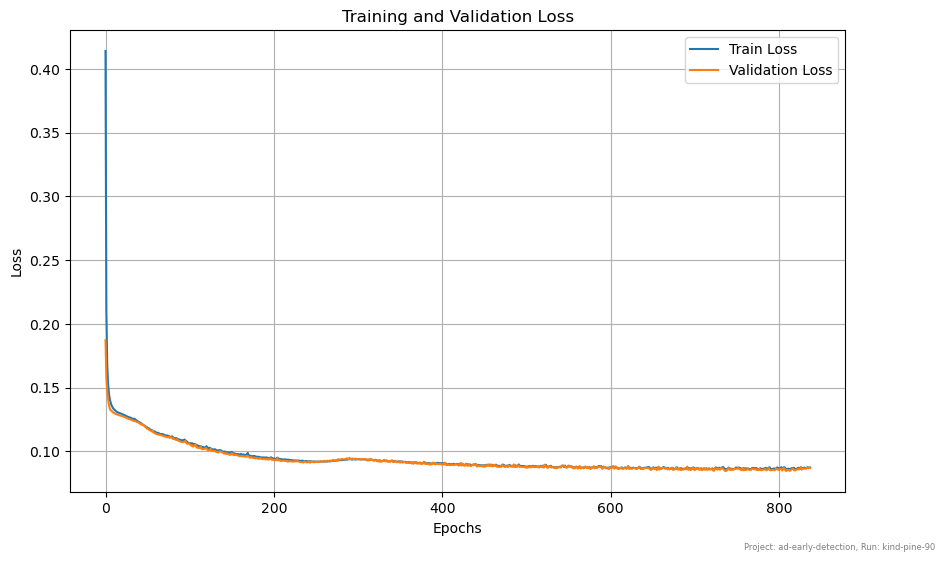

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.figtext(0.99, 0.01, f"Project: {WANDB_PROJECT}, Run: {wandb_run_name}", horizontalalignment='right', verticalalignment='bottom', fontsize=6, alpha=0.5)
plt.show()

In [11]:
# state = torch.load(str("../Fabian's models/200_Delcode_healthy_age_sex_conditioned/best_model_4000_epochs.pth"), map_location=device)
# model.load_state_dict(state)
# model.to(device)

## Loss

In [12]:
train_x_errors, train_adj_errors, train_total_weighted_errors, train_ids = \
    evaluate_reconstruction_errors_with_ids(train_dataset, model, device, adj_loss_weight=ADJ_LOSS_WEIGHT)
val_x_errors, val_adj_errors, val_total_weighted_errors, val_ids = \
    evaluate_reconstruction_errors_with_ids(val_dataset, model, device, adj_loss_weight=ADJ_LOSS_WEIGHT)

In [13]:
reconstruction_errors = {
    'Train': {
        'x_errors': train_x_errors,
        'adj_errors': train_adj_errors,
        'total_errors': train_total_weighted_errors,
        'patient_ids': train_ids
    },
    'Val': {
        'x_errors': val_x_errors,
        'adj_errors': val_adj_errors,
        'total_errors': val_total_weighted_errors,
        'patient_ids': val_ids
    }
}

for key in reconstruction_errors.keys():
    x_errors = reconstruction_errors[key]['x_errors']
    adj_errors = reconstruction_errors[key]['adj_errors']
    total_errors = reconstruction_errors[key]['total_errors']
    patient_ids = reconstruction_errors[key]['patient_ids']

    total_errors = np.array(total_errors)
    if total_errors.size == 0:
        reconstruction_errors[key]['x_errors'] = []
        reconstruction_errors[key]['adj_errors'] = []
        reconstruction_errors[key]['total_errors'] = []
        reconstruction_errors[key]['patient_ids'] = []
        continue

    valid_mask = ~np.isnan(total_errors)

    reconstruction_errors[key]['x_errors'] = np.array(x_errors)[valid_mask].tolist()
    reconstruction_errors[key]['adj_errors'] = np.array(adj_errors)[valid_mask].tolist()
    reconstruction_errors[key]['total_errors'] = total_errors[valid_mask].tolist()
    reconstruction_errors[key]['patient_ids'] = np.array(patient_ids)[valid_mask].tolist()

### Train vs. Validation

In [14]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, precision_recall_curve

train_errors = reconstruction_errors['Train']['total_errors']
val_errors = reconstruction_errors['Val']['total_errors']

all_errors = train_errors + val_errors

print(f"Total samples: {len(all_errors)}")
print(f"  Train: {len(train_errors)}")
print(f"  Val: {len(val_errors)}")

Total samples: 738
  Train: 627
  Val: 111


In [15]:
data = []
for dataset_name, errors in reconstruction_errors.items():
    total_errors = errors['total_errors']
    for error in total_errors:
        data.append({'Dataset': dataset_name, 'Total Error': error})

df = pd.DataFrame(data)
df = df.dropna(subset=['Total Error'])

label_map = {
    'Train': 'Train (All Cohorts)',
    'Val': 'Val (All Cohorts)'
}
df['Cohort'] = df['Dataset'].map(label_map)
df = df.dropna(subset=['Cohort'])
cohort_order = [
    'Train (All Cohorts)',
    'Val (All Cohorts)'
]

print(f"Dataset sizes:")
for cohort in cohort_order:
    count = len(df[df['Cohort'] == cohort])
    print(f"  {cohort}: {count}")

Dataset sizes:
  Train (All Cohorts): 627
  Val (All Cohorts): 111


/tmp/ipykernel_118833/1160065578.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


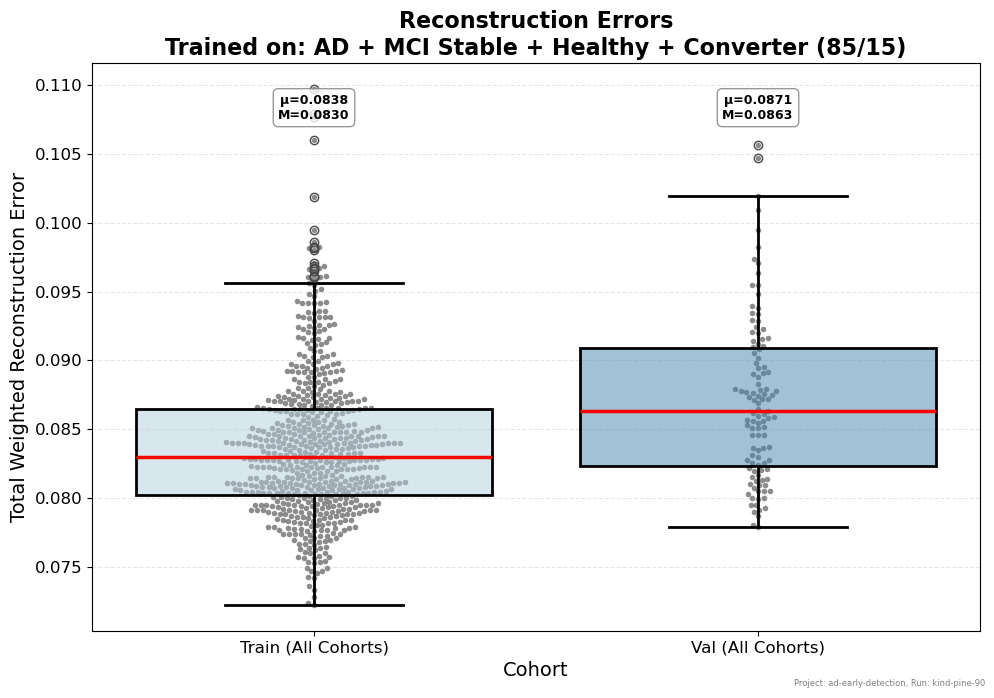

In [16]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.figure(figsize=(10, 7))
sns.swarmplot(
    x='Cohort', y='Total Error', data=df,
    order=cohort_order,
    color=".25", size=4, alpha=0.6, zorder=1
)

boxplot = sns.boxplot(
    x='Cohort', y='Total Error', data=df,
    order=cohort_order,
    palette='Blues',
    showcaps=True,
    boxprops={'edgecolor': 'black', 'linewidth': 2},
    medianprops={'color': 'red', 'linewidth': 2.5},
    whiskerprops={'color': 'black', 'linewidth': 2},
    capprops={'color': 'black', 'linewidth': 2},
    zorder=2
)

alpha_value = 0.5
for patch in boxplot.patches:
    facecolor = patch.get_facecolor()
    if len(facecolor) == 4:
        r, g, b, a = facecolor
    else:
        r, g, b = facecolor[:3]
        a = 1.0
    patch.set_facecolor((r, g, b, alpha_value))

for i, cohort in enumerate(cohort_order):
    cohort_data = df[df['Cohort'] == cohort]['Total Error']
    mean_val = cohort_data.mean()
    median_val = cohort_data.median()
    plt.text(i, plt.ylim()[1] * 0.98, f'μ={mean_val:.4f}\nM={median_val:.4f}', 
             ha='center', va='top', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.8))

plt.title('Reconstruction Errors\nTrained on: AD + MCI Stable + Healthy + Converter (85/15)', fontsize=16, fontweight='bold')
plt.xlabel('Cohort', fontsize=14)
plt.ylabel('Total Weighted Reconstruction Error', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.figtext(0.99, 0.01, f"Project: {WANDB_PROJECT}, Run: {wandb_run_name}", horizontalalignment='right', verticalalignment='bottom', fontsize=6, alpha=0.5)
plt.tight_layout()
plt.show()

### Healthy vs. AD vs. Converters vs. sMCI Boxplots

In [17]:
val_indices_in_subset = val_dataset.indices
val_indices_in_original = [training_indices[i] for i in val_indices_in_subset]

val_cohorts = {
    'AD': [],
    'MCI Stable': [],
    'Healthy': [],
    'Converter': []
}

for subset_idx, original_idx in zip(val_indices_in_subset, val_indices_in_original):
    for cohort_name, (start, end) in cohort_offsets.items():
        if start <= original_idx < end:
            val_cohorts[cohort_name].append(subset_idx)
            break

print(f"Validation cohort sizes:")
for cohort, indices in val_cohorts.items():
    print(f"  {cohort}: {len(indices)}")

Validation cohort sizes:
  AD: 10
  MCI Stable: 57
  Healthy: 34
  Converter: 10


In [18]:
from torch.utils.data import Subset

val_cohort_errors = {}

for cohort_name, cohort_indices in val_cohorts.items():
    cohort_subset = Subset(combined_dataset, cohort_indices)
    
    x_errors, adj_errors, total_errors, patient_ids = \
        evaluate_reconstruction_errors_with_ids(cohort_subset, model, device, adj_loss_weight=ADJ_LOSS_WEIGHT)
    
    total_errors = np.array(total_errors)
    valid_mask = ~np.isnan(total_errors)
    
    val_cohort_errors[cohort_name] = {
        'x_errors': np.array(x_errors)[valid_mask].tolist(),
        'adj_errors': np.array(adj_errors)[valid_mask].tolist(),
        'total_errors': total_errors[valid_mask].tolist(),
        'patient_ids': np.array(patient_ids)[valid_mask].tolist()
    }
    
    print(f"{cohort_name}: {len(total_errors[valid_mask])} valid samples")

AD: 10 valid samples
MCI Stable: 57 valid samples
Healthy: 34 valid samples
Converter: 10 valid samples


In [19]:
val_data = []
for cohort_name, errors in val_cohort_errors.items():
    total_errors = errors['total_errors']
    for error in total_errors:
        val_data.append({'Cohort': cohort_name, 'Total Error': error})

val_df = pd.DataFrame(val_data)
val_df = val_df.dropna(subset=['Total Error'])

val_cohort_order = ['Healthy', 'MCI Stable', 'Converter', 'AD']

print(f"Validation cohort sizes:")
for cohort in val_cohort_order:
    count = len(val_df[val_df['Cohort'] == cohort])
    print(f"  {cohort}: {count}")

Validation cohort sizes:
  Healthy: 34
  MCI Stable: 57
  Converter: 10
  AD: 10


/tmp/ipykernel_118833/1877024229.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


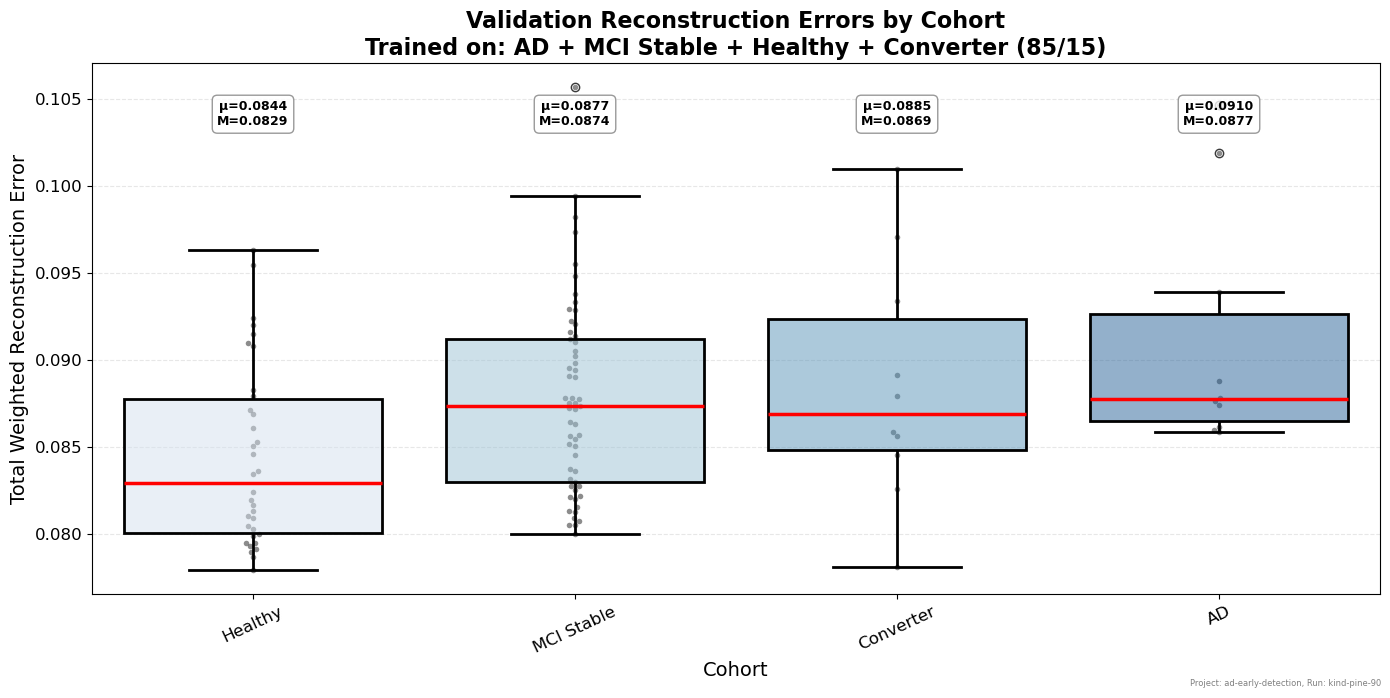

In [20]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.figure(figsize=(14, 7))
sns.swarmplot(
    x='Cohort', y='Total Error', data=val_df,
    order=val_cohort_order,
    color=".25", size=4, alpha=0.6, zorder=1
)

boxplot = sns.boxplot(
    x='Cohort', y='Total Error', data=val_df,
    order=val_cohort_order,
    palette='Blues',
    showcaps=True,
    boxprops={'edgecolor': 'black', 'linewidth': 2},
    medianprops={'color': 'red', 'linewidth': 2.5},
    whiskerprops={'color': 'black', 'linewidth': 2},
    capprops={'color': 'black', 'linewidth': 2},
    zorder=2
)

alpha_value = 0.5
for patch in boxplot.patches:
    r, g, b, _ = patch.get_facecolor()
    patch.set_facecolor((r, g, b, alpha_value))

for i, cohort in enumerate(val_cohort_order):
    cohort_data = val_df[val_df['Cohort'] == cohort]['Total Error']
    mean_val = cohort_data.mean()
    median_val = cohort_data.median()
    plt.text(i, plt.ylim()[1] * 0.98, f'μ={mean_val:.4f}\nM={median_val:.4f}', 
             ha='center', va='top', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.8))

plt.title('Validation Reconstruction Errors by Cohort\nTrained on: AD + MCI Stable + Healthy + Converter (85/15)', fontsize=16, fontweight='bold')
plt.xlabel('Cohort', fontsize=14)
plt.ylabel('Total Weighted Reconstruction Error', fontsize=14)
plt.xticks(rotation=25, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.figtext(0.99, 0.01, f"Project: {WANDB_PROJECT}, Run: {wandb_run_name}", horizontalalignment='right', verticalalignment='bottom', fontsize=6, alpha=0.5)
plt.tight_layout()
plt.show()

In [21]:
summary_table = df.groupby('Cohort')['Total Error'].agg(['count', 'mean', 'std', 'min', 'max']).reindex(cohort_order)

if 'run_artifact_dir' not in globals():
    run_artifact_dir = os.path.join("checkpoints", wandb_run_name)
    os.makedirs(run_artifact_dir, exist_ok=True)

loss_artifact = {
    'timestamp': datetime.now().strftime("%Y-%m-%d_%H-%M-%S"),
    'run_name': wandb_run_name,
    'model_path': model_file if 'model_file' in globals() else None,
    'dataset_info': dataset_info,
    'reconstruction_errors': reconstruction_errors,
    'cohort_dataframe': df.to_dict(orient="list"),
    'summary_table': summary_table.reset_index().to_dict(orient="list"),
    'cohort_order': cohort_order,
    'label_map': label_map
}

loss_filename = f"losses_{wandb_run_name}.pkl"
loss_file = os.path.join(run_artifact_dir, loss_filename)
with open(loss_file, "wb") as fp:
    pickle.dump(loss_artifact, fp)

print(f"Saved loss artifacts to {loss_file}")

Saved loss artifacts to checkpoints/kind-pine-90/losses_kind-pine-90.pkl


In [22]:
try:
    wandb.finish()
except Exception:
    pass

Train Loss,█▆▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Val Loss,█▇▅▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
Train Loss,0.08724
Val Loss,0.08694
